In [ ]:
import pandas as pd, pickle

train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train_data.csv')
test  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test_data.csv')
raw_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train_data_raw.csv')
raw_test  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test_data_raw.csv')

X_train = train.drop('target', axis=1)
y_train = train['target']
X_test  = test.drop('target', axis=1)
y_test  = test['target']

X_train_raw = raw_train.drop('target', axis=1)
y_train_raw = raw_train['target']
X_test_raw  = raw_test.drop('target', axis=1)
y_test_raw  = raw_test['target']

continuous_cols = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
]
cols_to_scale = continuous_cols
with open('/content/drive/MyDrive/Colab Notebooks/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
#Model Training on the Logistic Regression
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression model trained successfully!
Accuracy: 0.9132
Precision: 0.8671
Recall: 0.9190
F1-Score: 0.8923
ROC AUC Score: 0.9735

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       442
           1       0.87      0.92      0.89       284

    accuracy                           0.91       726
   macro avg       0.91      0.91      0.91       726
weighted avg       0.92      0.91      0.91       726


Confusion Matrix:
[[402  40]
 [ 23 261]]


In [ ]:
# now let's build model on the Random Forest

# n_estimators=100 means we are building 100 different trees to vote on the outcome
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

# 3. Make predictions on the SCALED test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("\nRandom Forest Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest model trained successfully!

Random Forest Metrics:
Accuracy:  0.9174
Precision: 0.9118
Recall:    0.8732
ROC AUC:   0.9682

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       442
           1       0.91      0.87      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



In [ ]:


# 1. Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,  # Shrinks the contribution of each tree to prevent overfitting
    max_depth=6,        # Standard depth for boosting
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

# 3. Predict on the SCALED test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("\nXGBoost Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:19:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully!

XGBoost Metrics:
Accuracy:  0.9256
Precision: 0.9167
Recall:    0.8908
ROC AUC:   0.9720

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       442
           1       0.92      0.89      0.90       284

    accuracy                           0.93       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



In [ ]:
from sklearn.ensemble import StackingClassifier

# 1. Define your Base Models (The 'Employees')
base_models = [
    ('lr', LogisticRegression(random_state=42, solver='liblinear')),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='logloss'))
]
# Logistic Regression is the industry standard for Meta-Learners
meta_learner = LogisticRegression()

# 3. Initialize and Train the Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5 # Uses cross-validation to train the meta-learner properly
)

stacking_model.fit(X_train, y_train)

print("Stacking Meta-Learner trained successfully!")

# 4. Evaluate the Performance
y_pred_stack = stacking_model.predict(X_test)
y_pred_proba_stack = stacking_model.predict_proba(X_test)[:, 1]

print("\nStacking Meta-Learner Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_stack):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

Stacking Meta-Learner trained successfully!

Stacking Meta-Learner Metrics:
Accuracy:  0.9298
ROC AUC:   0.9743

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       442
           1       0.90      0.93      0.91       284

    accuracy                           0.93       726
   macro avg       0.92      0.93      0.93       726
weighted avg       0.93      0.93      0.93       726



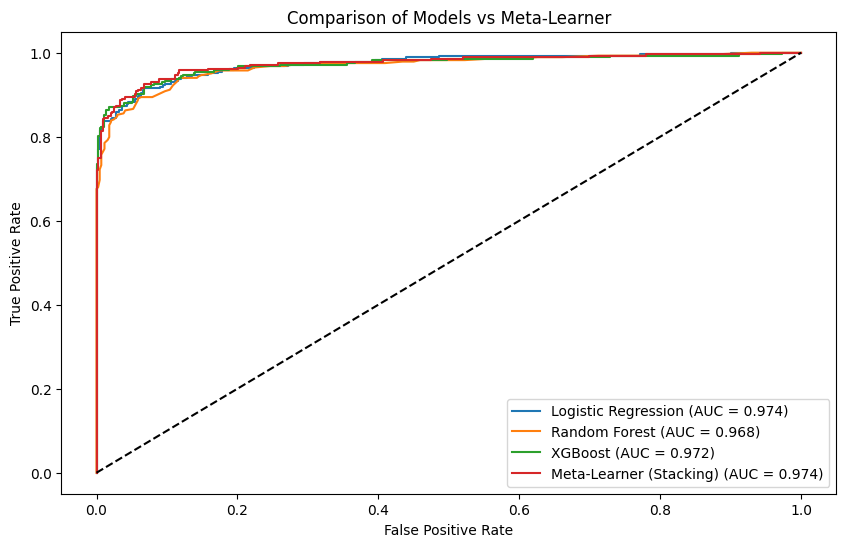

In [ ]:
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': y_pred_proba, # Use your existing proba variables
    'Random Forest': y_pred_proba_rf,
    'XGBoost': y_pred_proba_xgb,
    'Meta-Learner (Stacking)': y_pred_proba_stack
}

plt.figure(figsize=(10, 6))
for name, probs in models.items():
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of Models vs Meta-Learner')
plt.legend()
plt.show()

/tmp/ipykernel_249/1722971114.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


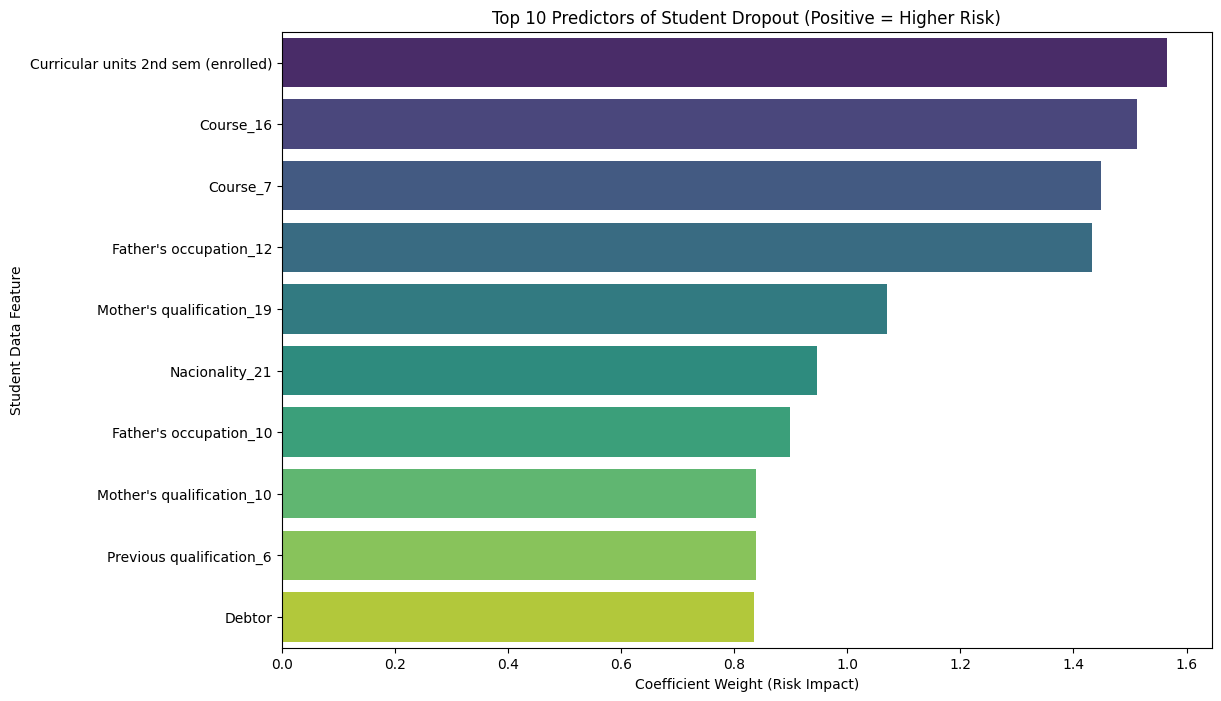

/tmp/ipykernel_249/1722971114.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.tail(10), palette='magma')


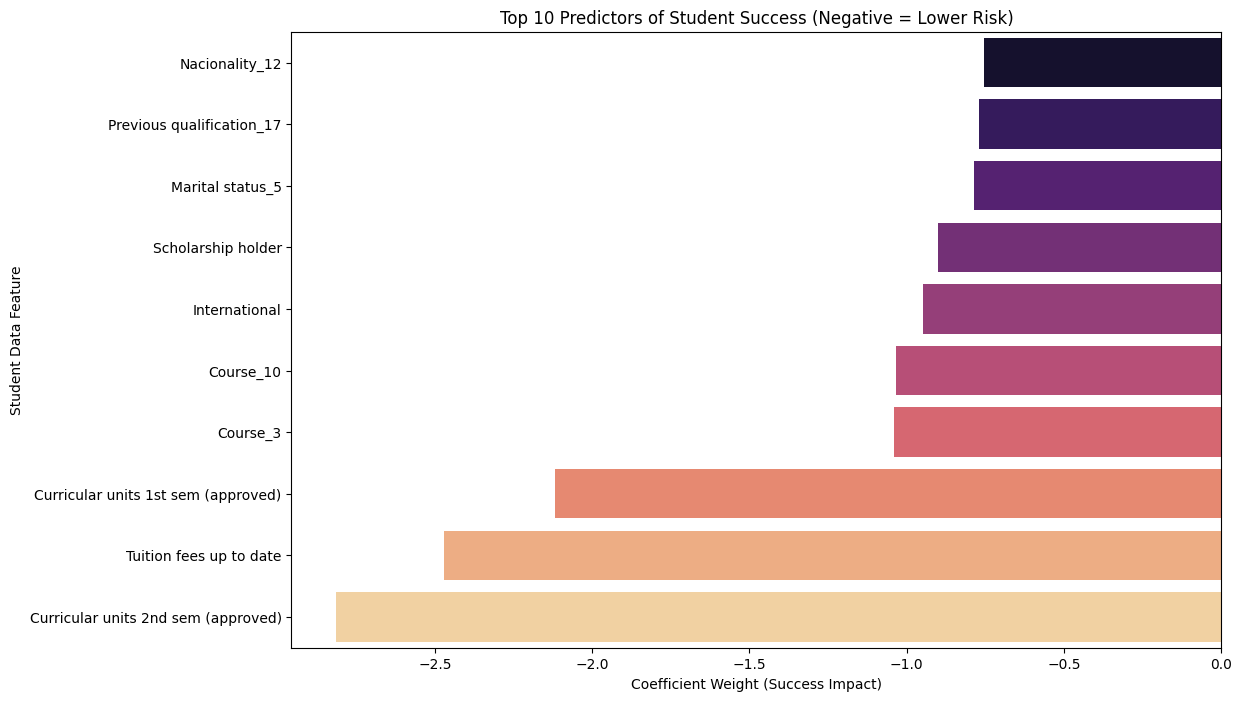

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Let's use the Logistic Regression base model for the clearest interpretation
importance = model.coef_[0]
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plotting the top 10 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Predictors of Student Dropout (Positive = Higher Risk)')
plt.xlabel('Coefficient Weight (Risk Impact)')
plt.ylabel('Student Data Feature')
plt.show()

# Plotting the bottom 10 (Protective factors)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.tail(10), palette='magma')
plt.title('Top 10 Predictors of Student Success (Negative = Lower Risk)')
plt.xlabel('Coefficient Weight (Success Impact)')
plt.ylabel('Student Data Feature')
plt.show()

In [15]:
import pandas as pd
enrolled_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/enrolled_inference.csv')
risk_probabilities = stacking_model.predict_proba(enrolled_df)[:, 1]

# 3. Create the report
risk_report = pd.DataFrame({
    'Student_ID': enrolled_df.index,
    'Dropout_Probability': (risk_probabilities * 100).round(2),
})

# 4. Assign Human-Readable Risk Levels
def assign_risk_label(prob):
    if prob >= 80: return ' CRITICAL (Intervene Now)'
    if prob >= 60: return ' HIGH (Priority Support)'
    if prob >= 40: return ' MEDIUM (Monitor)'
    return ' LOW (On Track)'

risk_report['Risk_Status'] = risk_report['Dropout_Probability'].apply(assign_risk_label)

# 5. Sort by most at-risk students first
risk_report = risk_report.sort_values(by='Dropout_Probability', ascending=False)

# 6. Save as a CSV for the administration team
risk_report.to_csv('student_risk_report.csv', index=False)

print(" Risk Report Generated!")
print("\n")
print(risk_report.head(10))
print("\n")
print(risk_report.tail(10))

 Risk Report Generated!


     Student_ID  Dropout_Probability                Risk_Status
553         553                98.83   CRITICAL (Intervene Now)
32           32                98.78   CRITICAL (Intervene Now)
390         390                98.77   CRITICAL (Intervene Now)
771         771                98.76   CRITICAL (Intervene Now)
352         352                98.75   CRITICAL (Intervene Now)
487         487                98.75   CRITICAL (Intervene Now)
630         630                98.75   CRITICAL (Intervene Now)
332         332                98.70   CRITICAL (Intervene Now)
484         484                98.70   CRITICAL (Intervene Now)
509         509                98.69   CRITICAL (Intervene Now)


     Student_ID  Dropout_Probability      Risk_Status
470         470                 3.20   LOW (On Track)
763         763                 3.19   LOW (On Track)
409         409                 2.97   LOW (On Track)
507         507                 2.92   LOW (On Track

In [16]:

with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('lr_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('stacking_model.pkl', 'wb') as f:
    pickle.dump(stacking_model, f)

print("All models saved!")

All models saved!
